# Explainable Deep Learning Framework for Antibiotic Resistance Detection via Single-Cell Bacterial Morphology Analysis

**Import**

In [33]:
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", font_scale=1.2)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: []


**Configuration**

In [34]:
# Dataset path (change this to your local path)
DATASET_PATH = Path(r"C:\Users\subas\PycharmProjects\JupyterProject\data\data")

# Output folder for quick test
OUTPUT_DIR = Path("quick_test_cells")
OUTPUT_DIR.mkdir(exist_ok=True)

# Parameters
MAX_CELLS_PER_CLASS =1500
TARGET_SIZE = (64, 64)

# Folder mapping
CLASS_MAP = {
    "BEFORE": "WT+ETOH",
    "AFTER": "CIP+ETOH"
}


**Utility Functions**

In [35]:
def resize_with_padding(img, target_size=(64,64)):
    h, w = img.shape[:2]
    th, tw = target_size

    scale = min(th/h, tw/w)
    nh, nw = int(h*scale), int(w*scale)

    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    padded = np.zeros((th, tw, 3), dtype=resized.dtype)

    yoff = (th - nh) // 2
    xoff = (tw - nw) // 2

    padded[yoff:yoff+nh, xoff:xoff+nw] = resized
    return padded


def normalize(img):
    img = img.astype(np.float32)
    if img.max() > 0:
        img /= img.max()
    return img


**Cell Extraction**

In [36]:
def extract_cells_from_fov(img_path, mask_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

    if img is None or mask is None:
        return []

    # Channel handling
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    elif img.shape[2] == 2:
        rgb = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.float32)
        rgb[:,:,0] = img[:,:,1]
        rgb[:,:,1] = img[:,:,0]
        img = rgb
    elif img.shape[2] > 3:
        img = img[:,:,:3]

    img = normalize(img)

    cell_ids = np.unique(mask)
    cell_ids = cell_ids[cell_ids > 0]

    cells = []

    for cid in cell_ids:
        m = (mask == cid)
        if m.sum() < 10:
            continue

        ys, xs = np.where(m)
        y1, y2 = ys.min(), ys.max()
        x1, x2 = xs.min(), xs.max()

        crop = img[y1:y2+1, x1:x2+1]
        crop = resize_with_padding(crop, TARGET_SIZE)
        cells.append(crop)

    return cells


////

**Viusalize extracted cell**

In [37]:
img_dir = DATASET_PATH / "MG1655" / "All_images"
seg_dir = DATASET_PATH / "MG1655" / "All_segmentations"

for category, folder in CLASS_MAP.items():
    print(f"\nExtracting: {category}")

    out_dir = OUTPUT_DIR / category
    out_dir.mkdir(parents=True, exist_ok=True)

    imgs = list((img_dir / folder).glob("*.tif*"))
    np.random.shuffle(imgs)

    total = 0

    for img_path in tqdm(imgs):
        if total >= MAX_CELLS_PER_CLASS:
            break

        seg_path = (seg_dir / folder / img_path.name)
        if not seg_path.exists():
            continue

        cells = extract_cells_from_fov(img_path, seg_path)

        for cell in cells:
            if total >= MAX_CELLS_PER_CLASS:
                break
            np.save(out_dir / f"cell_{total:04d}.npy", cell)
            total += 1

    print(f"  Saved {total} cells")



Extracting: BEFORE


  6%|▌         | 28/455 [00:05<01:22,  5.15it/s]


  Saved 1500 cells

Extracting: AFTER


 10%|█         | 29/285 [00:03<00:33,  7.75it/s]

  Saved 1500 cells


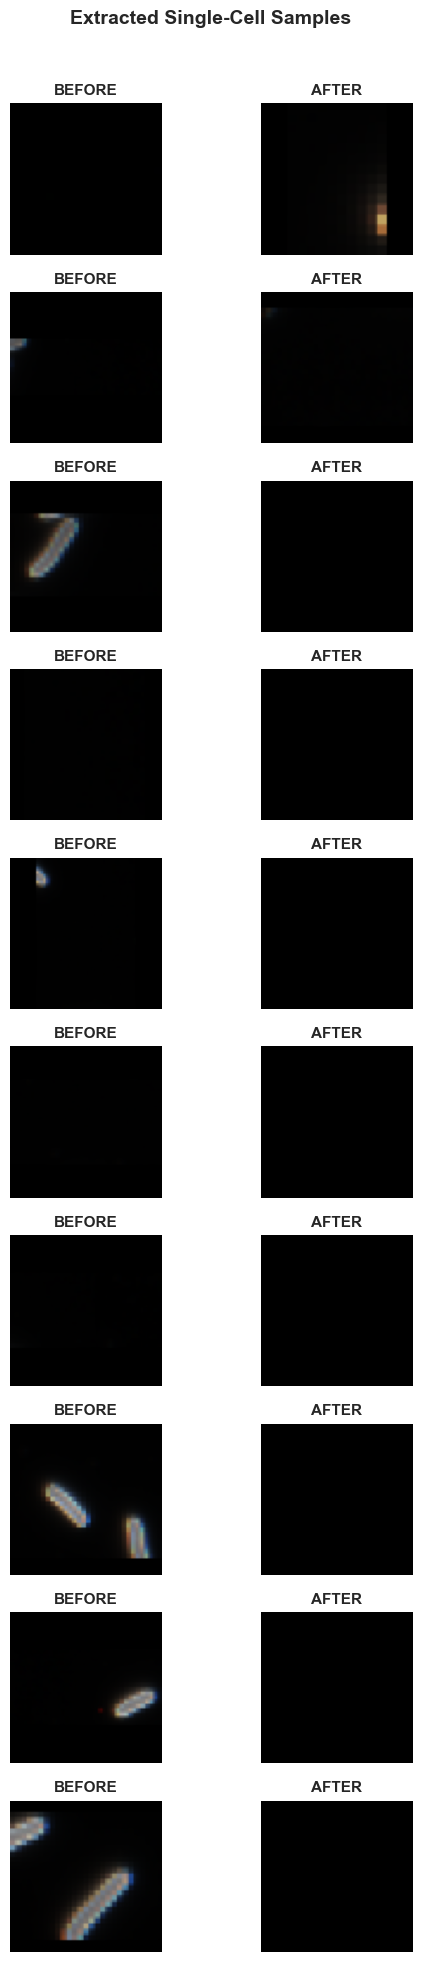

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="white")

before = list((OUTPUT_DIR/"BEFORE").glob("*.npy"))[:10]
after  = list((OUTPUT_DIR/"AFTER").glob("*.npy"))[:10]

n = min(len(before), len(after))

fig, axes = plt.subplots(n, 2, figsize=(6, 2*n))

for i in range(n):
    axes[i,0].imshow(np.load(before[i]))
    axes[i,0].set_title("BEFORE", fontsize=11, weight="bold")
    axes[i,0].axis("off")

    axes[i,1].imshow(np.load(after[i]))
    axes[i,1].set_title("AFTER", fontsize=11, weight="bold")
    axes[i,1].axis("off")

plt.suptitle("Extracted Single-Cell Samples", fontsize=14, weight="bold")
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


**Training Datasets**

In [142]:
X, y = [], []

for f in (OUTPUT_DIR/"BEFORE").glob("*.npy"):
    X.append(np.load(f))
    y.append(0)

for f in (OUTPUT_DIR/"AFTER").glob("*.npy"):
    X.append(np.load(f))
    y.append(1)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

X, y = shuffle(X, y, random_state=42)

print("Total samples:", len(X))
print("Class balance:", np.bincount(y))


Total samples: 400
Class balance: [200 200]


In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))


Train: 280
Test: 120


**CNN MODEL BUILDING**

In [144]:
model = keras.Sequential([
    keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(64,64,3)),
    keras.layers.MaxPooling2D(2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Users\subas\PycharmProjects\JupyterProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,801 (8.07 MB)

 Trainable params: 2,116,801 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Evaluation**

In [145]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16
)


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.5089 - loss: 0.6579 - val_accuracy: 0.5893 - val_loss: 0.6820
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5804 - loss: 0.6179 - val_accuracy: 0.5893 - val_loss: 0.6713
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6161 - loss: 0.5969 - val_accuracy: 0.6071 - val_loss: 0.6690
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6384 - loss: 0.5807 - val_accuracy: 0.6071 - val_loss: 0.6864
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6295 - loss: 0.5626 - val_accuracy: 0.6071 - val_loss: 0.6716
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6429 - loss: 0.5463 - val_accuracy: 0.6071 - val_loss: 0.8406
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6473 - loss: 0.5691 - val_accuracy: 0.6250 - val_loss: 0.6955
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6696 - loss: 0.5237 - val_accuracy: 0.6250 - v

**Confusion matrix**

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


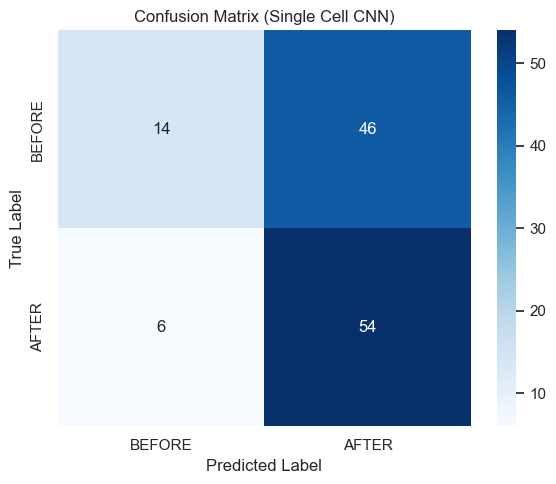

In [146]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)

labels = ["BEFORE", "AFTER"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Single Cell CNN)")
plt.tight_layout()
plt.show()


**Model Accuracy and Loss**

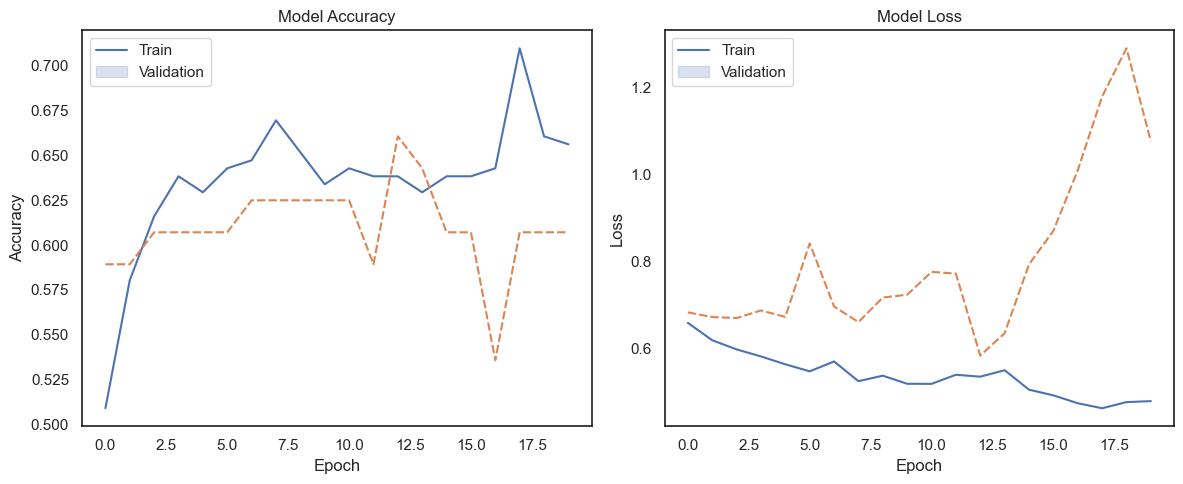

In [147]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
sns.lineplot(data=history_df[['accuracy','val_accuracy']])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

# Loss
plt.subplot(1,2,2)
sns.lineplot(data=history_df[['loss','val_loss']])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()


**Confidence Distribution**

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


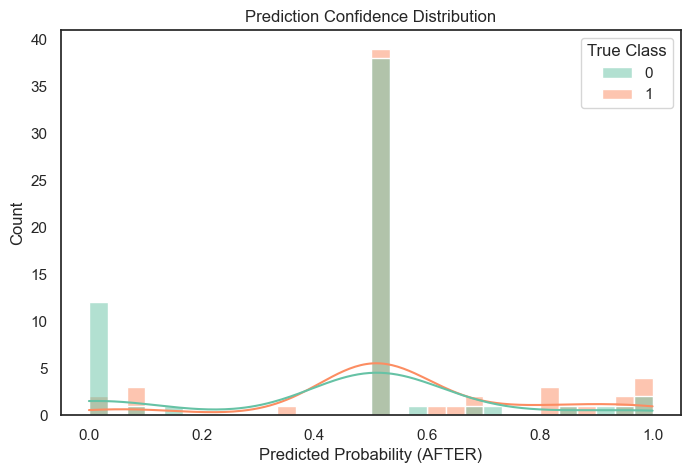

In [148]:
pred_probs = model.predict(X_test).flatten()

df_preds = pd.DataFrame({
    "Prediction Probability": pred_probs,
    "True Class": y_test
})

plt.figure(figsize=(8,5))
sns.histplot(data=df_preds, x="Prediction Probability",
             hue="True Class", bins=30, kde=True, palette="Set2")

plt.title("Prediction Confidence Distribution")
plt.xlabel("Predicted Probability (AFTER)")
plt.ylabel("Count")
plt.show()


**ROC CURVE**

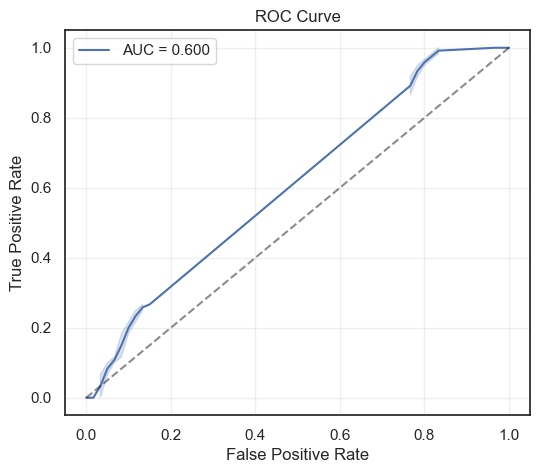

In [149]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Class wise Normalize Accuracy

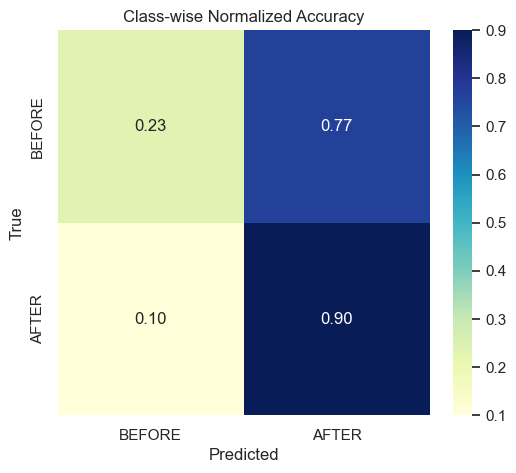

In [150]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

df_acc = pd.DataFrame(cm_norm, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(df_acc, annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Class-wise Normalized Accuracy")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
